# Perceptron Algorithm

## Learning Objectives
- Distinguish **batch learning** (train then test) from **online learning** (predict and update simultaneously)
- Understand the perceptron hypothesis $h_\theta(x) = g(\theta^T x)$ with labels $y \in \{-1, +1\}$
- Implement the perceptron update rule $\theta := \theta + y x$ triggered on misclassification
- Visualise how the decision boundary evolves as the perceptron processes examples
- Understand that the perceptron is the simplest large-margin classifier and converges on linearly-separable data

## Problem Statement

### Online Learning Setting
The algorithm sees examples one at a time in order $(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \ldots$
- First it predicts $\hat{y}^{(i)}$ for $x^{(i)}$
- Then the true $y^{(i)}$ is revealed
- The algorithm updates and moves on

The goal is to minimise the **total number of mistakes** over the sequence.

### Perceptron Hypothesis
With $\theta \in \mathbb{R}^{n+1}$ and labels $y \in \{-1, +1\}$:
$$h_\theta(x) = g(\theta^T x), \qquad g(z) = \begin{cases} +1 & z \geq 0 \\ -1 & z < 0 \end{cases}$$

### Update Rule
Only update when the prediction is wrong:
$$\text{if } h_\theta(x^{(i)}) \neq y^{(i)}: \quad \theta := \theta + y^{(i)} x^{(i)}$$

**Intuition:** if $y^{(i)} = +1$ and we predicted $-1$, then $\theta^T x < 0$; adding $x$ increases $\theta^T x$ toward correct classification. Symmetric for $y^{(i)} = -1$.

## 1. Batch vs. Online Learning

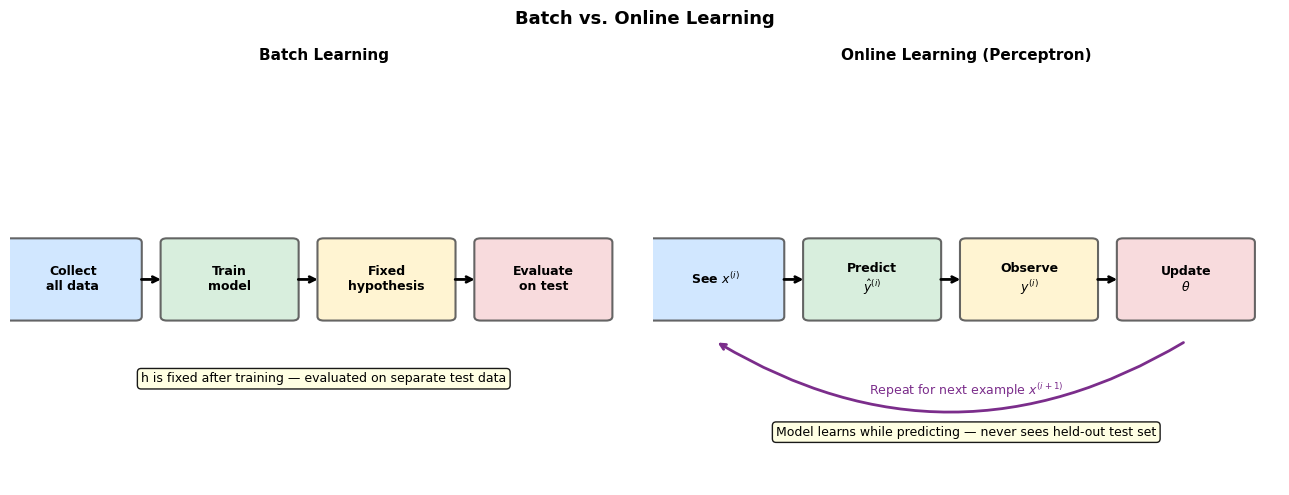

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def draw_pipeline(ax, title, steps, colors):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
    y_pos = 5.0
    x_positions = [1.0 + i * 2.5 for i in range(len(steps))]
    for x, step, color in zip(x_positions, steps, colors):
        ax.add_patch(FancyBboxPatch((x - 1.0, y_pos - 0.9), 2.0, 1.8,
                     boxstyle='round,pad=0.1', fc=color, ec='#555', lw=1.5, alpha=0.9))
        ax.text(x, y_pos, step, ha='center', va='center', fontsize=9, fontweight='bold')
    for i in range(len(x_positions) - 1):
        ax.annotate('', xy=(x_positions[i+1] - 1.05, y_pos),
                    xytext=(x_positions[i] + 1.05, y_pos),
                    arrowprops=dict(arrowstyle='->', color='k', lw=2))
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

# Batch learning
draw_pipeline(axes[0], 'Batch Learning',
    ['Collect\nall data', 'Train\nmodel', 'Fixed\nhypothesis', 'Evaluate\non test'],
    ['#cce5ff', '#d4edda', '#fff3cd', '#f8d7da'])
axes[0].text(5, 2.5, 'h is fixed after training — evaluated on separate test data',
             ha='center', fontsize=9,
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# Online learning
draw_pipeline(axes[1], 'Online Learning (Perceptron)',
    ['See $x^{(i)}$', 'Predict\n$\\hat{y}^{(i)}$', 'Observe\n$y^{(i)}$', 'Update\n$\\theta$'],
    ['#cce5ff', '#d4edda', '#fff3cd', '#f8d7da'])
# Loop-back arrow
axes[1].annotate('', xy=(1.0, 3.5), xytext=(8.5, 3.5),
                 arrowprops=dict(arrowstyle='->', color='#7b2d8b', lw=2,
                                 connectionstyle='arc3,rad=-0.3'))
axes[1].text(5, 2.2, 'Repeat for next example $x^{(i+1)}$',
             ha='center', fontsize=9, color='#7b2d8b')
axes[1].text(5, 1.2, 'Model learns while predicting — never sees held-out test set',
             ha='center', fontsize=9,
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

fig.suptitle('Batch vs. Online Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Perceptron Algorithm Implementation

In [7]:
import numpy as np

def perceptron_train(X, y, max_passes=20):
    """
    Online perceptron: processes examples in sequence, updates on mistakes.
    Labels must be in {-1, +1}.
    Returns theta, total mistakes, history of (theta, mistake_index) per update.
    """
    n = X.shape[1]
    theta   = np.zeros(n)
    history = []          # (theta snapshot, example index, pass number)
    total_mistakes = 0

    for pass_num in range(max_passes):
        mistakes_this_pass = 0
        for i in range(len(X)):
            pred = np.sign(theta @ X[i])
            if pred == 0:
                pred = 1
            if pred != y[i]:
                # Update rule: theta := theta + y * x
                theta = theta + y[i] * X[i]
                history.append((theta.copy(), i, pass_num))
                total_mistakes += 1
                mistakes_this_pass += 1
        if mistakes_this_pass == 0:
            break   # converged

    return theta, total_mistakes, history


def perceptron_predict(X, theta):
    scores = X @ theta
    return np.where(scores >= 0, 1, -1)


# Quick smoke test
import numpy as np
np.random.seed(0)

X_test = np.array([[1, 2], [2, 1], [-1, -2], [-2, -1]], dtype=float)
y_test = np.array([1, 1, -1, -1])

theta_final, mistakes, hist = perceptron_train(X_test, y_test)
print(f'Theta: {theta_final}')
print(f'Total mistakes: {mistakes}')
print(f'Predictions: {perceptron_predict(X_test, theta_final)}')
print(f'Accuracy: {np.mean(perceptron_predict(X_test, theta_final) == y_test):.0%}')

Theta: [1. 2.]
Total mistakes: 1
Predictions: [ 1  1 -1 -1]
Accuracy: 100%


## 3. Visualising the Perceptron Update Steps

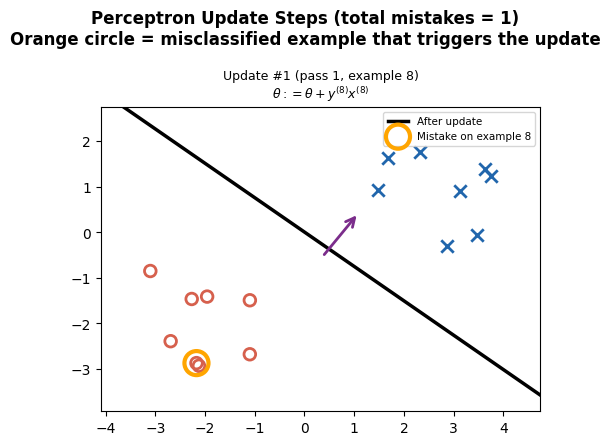

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Linearly separable 2D dataset
X_pos = np.random.randn(8, 2) + [2, 2]
X_neg = np.random.randn(8, 2) + [-2, -2]
X     = np.vstack([X_pos, X_neg])
y     = np.array([1]*8 + [-1]*8)

theta_final, total_mistakes, history = perceptron_train(X, y)

n_show = min(6, len(history))

if n_show == 0:
    print("No mistakes — perceptron converged immediately.")
else:
    ncols = min(n_show, 3)
    nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5), squeeze=False)
    axes_flat = axes.flatten()

    xmin, xmax = X[:,0].min()-1, X[:,0].max()+1
    ymin, ymax = X[:,1].min()-1, X[:,1].max()+1
    x_line = np.linspace(xmin, xmax, 200)

    theta_prev = np.zeros(2)

    for idx in range(n_show):
        ax = axes_flat[idx]
        theta_snap, mistake_i, pass_num = history[idx]

        # Draw previous boundary (before update)
        if np.abs(theta_prev[1]) > 1e-8:
            y_prev = -theta_prev[0] / theta_prev[1] * x_line
            ax.plot(x_line, y_prev, 'gray', lw=1.5, ls='--', alpha=0.5, label='Before update')

        # Draw new boundary (after update)
        if np.abs(theta_snap[1]) > 1e-8:
            y_new = -theta_snap[0] / theta_snap[1] * x_line
            ax.plot(x_line, y_new, 'k-', lw=2.5, label='After update')

        # Plot all points
        ax.scatter(X_pos[:,0], X_pos[:,1], marker='x', c='#2166ac', s=80, lw=2)
        ax.scatter(X_neg[:,0], X_neg[:,1], marker='o', s=70,
                   facecolors='none', edgecolors='#d6604d', lw=2)

        # Highlight the misclassified example that triggered this update
        ax.scatter(X[mistake_i, 0], X[mistake_i, 1], s=300,
                   facecolors='none', edgecolors='orange', lw=3, zorder=6,
                   label=f'Mistake on example {mistake_i}')

        # theta arrow
        cx, cy = np.mean(X, axis=0)
        norm = np.linalg.norm(theta_snap) + 1e-8
        ax.annotate('', xytext=(cx, cy),
                    xy=(cx + 1.2 * theta_snap[0]/norm, cy + 1.2 * theta_snap[1]/norm),
                    arrowprops=dict(arrowstyle='->', color='#7b2d8b', lw=2, mutation_scale=16))

        ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
        ax.set_title(f'Update #{idx+1} (pass {pass_num+1}, example {mistake_i})\n'
                     f'$\\theta := \\theta + y^{{({mistake_i})}}x^{{({mistake_i})}}$',
                     fontsize=9)
        ax.legend(fontsize=7.5, loc='upper right')

        theta_prev = theta_snap

    fig.suptitle(f'Perceptron Update Steps (total mistakes = {total_mistakes})\n'
                 'Orange circle = misclassified example that triggers the update',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Convergence on Linearly Separable Data

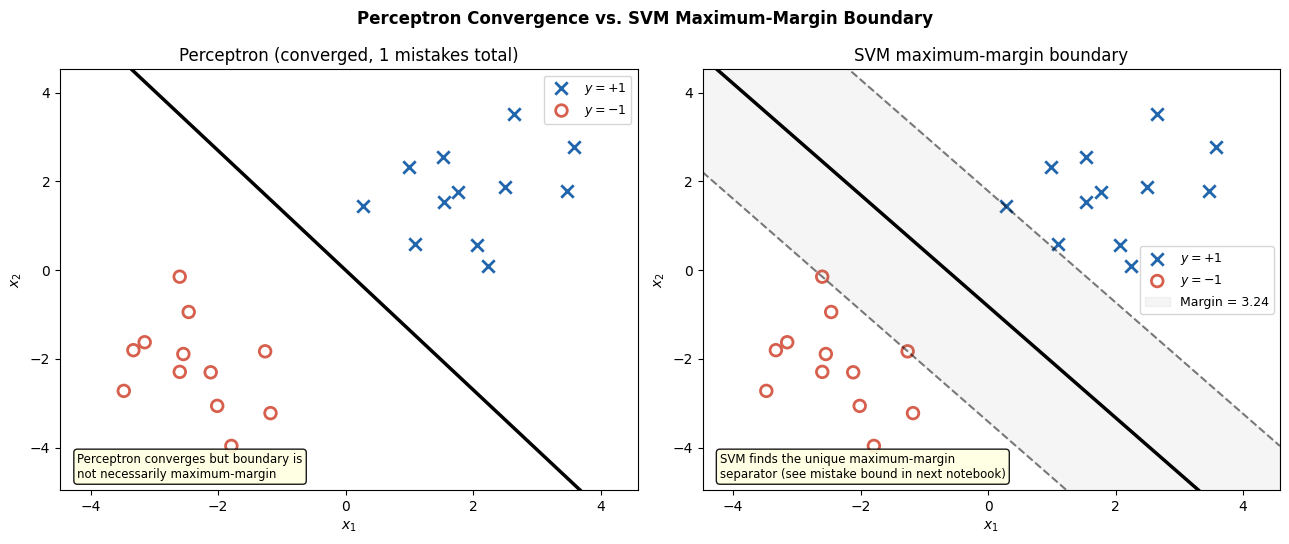

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Show final converged boundary vs. SVM maximum-margin boundary
from sklearn.svm import SVC

X_pos = np.random.randn(12, 2) + [2, 2]
X_neg = np.random.randn(12, 2) + [-2, -2]
X     = np.vstack([X_pos, X_neg])
y_pm  = np.array([1]*12 + [-1]*12)   # {-1,+1} for perceptron
y_01  = np.array([1]*12 + [0]*12)    # {0,1} for sklearn SVM

theta_p, mistakes, _ = perceptron_train(X, y_pm)

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y_pm)
w_svm = clf.coef_[0]
b_svm = clf.intercept_[0]

xmin, xmax = X[:,0].min()-1, X[:,0].max()+1
x_line = np.linspace(xmin, xmax, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, title, theta, b in [
    (axes[0], f'Perceptron (converged, {mistakes} mistakes total)', theta_p, 0),
    (axes[1], 'SVM maximum-margin boundary', w_svm, b_svm)
]:
    if np.abs(theta[1]) > 1e-8:
        y_line = -(theta[0] * x_line + b) / theta[1]
        ax.plot(x_line, y_line, 'k-', lw=2.5)

    ax.scatter(X_pos[:,0], X_pos[:,1], marker='x', c='#2166ac', s=80, lw=2, label='$y=+1$')
    ax.scatter(X_neg[:,0], X_neg[:,1], marker='o', s=70,
               facecolors='none', edgecolors='#d6604d', lw=2, label='$y=-1$')

    if title.startswith('SVM'):
        margin = 2 / np.linalg.norm(w_svm)
        y_m_pos = -(w_svm[0]*x_line + b_svm - 1) / w_svm[1]
        y_m_neg = -(w_svm[0]*x_line + b_svm + 1) / w_svm[1]
        ax.plot(x_line, y_m_pos, 'k--', lw=1.5, alpha=0.5)
        ax.plot(x_line, y_m_neg, 'k--', lw=1.5, alpha=0.5)
        ax.fill_between(x_line, y_m_neg, y_m_pos, alpha=0.08, color='gray',
                        label=f'Margin = {margin:.2f}')

    ax.set_xlim(xmin, xmax); ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(title); ax.legend(fontsize=9)

axes[0].text(0.03, 0.03,
    'Perceptron converges but boundary is\nnot necessarily maximum-margin',
    transform=axes[0].transAxes, fontsize=8.5,
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))
axes[1].text(0.03, 0.03,
    'SVM finds the unique maximum-margin\nseparator (see mistake bound in next notebook)',
    transform=axes[1].transAxes, fontsize=8.5,
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

fig.suptitle('Perceptron Convergence vs. SVM Maximum-Margin Boundary',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Derivation Pathway

### Derivation pathway

In [10]:
from IPython.display import HTML
HTML("""
<svg xmlns="http://www.w3.org/2000/svg" width="780" height="374"
     viewBox="0 0 780 374" font-family="Segoe UI, Arial, sans-serif">
  <defs>
    <marker id="ah" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#444"/>
    </marker>
    <marker id="ahd" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#999"/>
    </marker>
  </defs>

  <!-- Row 1: See example -->
  <rect x="10" y="12" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="35" font-size="12.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">See example</text>
  <text x="102" y="52" font-size="12.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">(x&#x2071;, y&#x2071;)</text>
  <line x1="197" y1="35" x2="216" y2="35"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="12" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="40" font-size="13" text-anchor="middle" fill="#333"
        >online learning: predict before observing true label</text>

  <!-- step 1&#x2192;2 -->
  <line x1="102" y1="58" x2="102" y2="108"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="82" font-size="11.5" font-style="italic" fill="#555"
        >predict: &#x125;&#x2071; = g(&#x3b8;&#x1d40;x&#x2071;), g(z) = sign(z)</text>

  <!-- Row 2: Predict -->
  <rect x="10" y="112" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="140" font-size="13.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Predict &#x125;&#x2071;</text>
  <line x1="197" y1="135" x2="216" y2="135"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="112" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="140" font-size="13" text-anchor="middle" fill="#333"
        >if correct: no update; if wrong: update rule fires</text>

  <!-- step 2&#x2192;3 -->
  <line x1="102" y1="158" x2="102" y2="208"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="114" y="182" font-size="11.5" font-style="italic" fill="#555"
        >if &#x125;&#x2071; &#x2260; y&#x2071;: &#x3b8; := &#x3b8; + y&#x2071; x&#x2071;</text>

  <!-- Row 3: Update -->
  <rect x="10" y="212" width="185" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="102" y="240" font-size="13.5" font-weight="600"
        text-anchor="middle" fill="#2166ac">Update &#x3b8;</text>
  <line x1="197" y1="235" x2="216" y2="235"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="212" width="548" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="495" y="240" font-size="13" text-anchor="middle" fill="#333"
        >adding y&#x2071;x&#x2071; increases &#x3b8;&#x1d40;x&#x2071; in the direction of correct classification</text>

  <!-- step 3&#x2192;4 -->
  <line x1="102" y1="258" x2="102" y2="308"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>

  <!-- Row 4: Convergence -->
  <rect x="10" y="312" width="185" height="46" rx="7"
        fill="#1a5fa8" stroke="#1a5fa8" stroke-width="2"/>
  <text x="102" y="340" font-size="13.5" font-weight="700"
        text-anchor="middle" fill="#ffffff">Convergence</text>
  <line x1="197" y1="335" x2="216" y2="335"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="221" y="312" width="548" height="46" rx="7"
        fill="#dce8f8" stroke="#7aadd4" stroke-width="1.5"/>
  <text x="495" y="340" font-size="13" text-anchor="middle" fill="#333"
        >if data is linearly separable, converges in finite steps &#x2014; mistake bound in next notebook</text>
</svg>
""")

## Summary

| Concept | Formula / Description | Key Insight |
|---|---|---|
| Hypothesis | $h_\theta(x) = g(\theta^T x),\ g(z) = \text{sign}(z)$ | Labels $\in \{-1, +1\}$ |
| Update rule | $\theta := \theta + y^{(i)} x^{(i)}$ if $h_\theta(x^{(i)}) \neq y^{(i)}$ | Only updates on mistakes |
| Update intuition | Adds $y^{(i)} x^{(i)}$ to $\theta$ | Increases $\theta^T x^{(i)}$ toward correct sign |
| Online setting | Predict, observe label, update — then move to next example | No held-out test set |
| Convergence | Guaranteed on linearly separable data | Total mistakes is bounded |
| vs. SVM | Perceptron converges but not maximum-margin | SVM finds the unique maximum-margin boundary |

**Key insight:** the perceptron update rule $\theta := \theta + y^{(i)} x^{(i)}$ is geometrically intuitive — it rotates the decision hyperplane toward the misclassified point; on linearly separable data it converges in a finite number of steps bounded by the margin of the data.